<div style="background-color: black; color: white; padding: 10px;text-align: center;">
  <strong>Date Published:</strong>  Oct 8, 2026 <strong>Author:</strong> Adnan Alaref
</div>

## Baseline 5 — Model B

This baseline extends the previous player-level temporal action recognition model to **group-level activity recognition**. For each volleyball group, temporal features are extracted from all detected players and aggregated to predict one of **8 group activity classes**. The __player-level model__ is used as the __feature extractor__, while Model B learns how to combine information across multiple players for group-level classification.

| # | Previous Work | Description |
|---|---|---|
| 1 | [Baseline 5 — Player-Level Temporal Action Recognition](https://www.kaggle.com/code/adnanalaref/baseline5-player-level-temporal-action-recognition) | Player-level temporal action recognition |
| 2 | **Baseline 5 — Model B** | Group-level action recognition using player temporal features |

# Step 1: Import Library.

In [29]:
# !uv pip uninstall --system -y torch torchvision torchaudio >/dev/null 2>&1

In [30]:
# !uv pip install --system torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0  >/dev/null 2>&1

In [31]:
# !uv pip install --system numpy==1.26.4 pandas==2.2.2 seaborn==0.13.2 --no-cache-dir >/dev/null 2>&1

In [32]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))

2.11.0+cu128
12.8
Tesla T4
(7, 5)


In [33]:
import numpy as np
import pandas as pd
import seaborn as sns

print(np.__version__)
print(pd.__version__)
print(sns.__version__)

2.1.3
2.3.3
0.13.2


In [34]:
import re
import os
import cv2
import torch
import random
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms.v2 as T
import torchvision.transforms.v2.functional as TF


from pathlib import Path
from pprint import pprint
from tqdm.auto import tqdm
from PIL import Image, ImageOps
from collections import Counter
from torch.cuda.amp import autocast
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import f1_score, classification_report
from typing import Dict, List, TypeVar, Tuple, Any, Callable, Optional

import warnings
warnings.simplefilter(action='ignore')
warnings.filterwarnings(action='ignore', category=FutureWarning)

# Step 2: Collect Player Temporal Data From Clips With 9 Frames Include Middle Image.

In [35]:
dataset_root = r"/kaggle/input/datasets/sherif31/group-activity-recognition-volleyball"

In [36]:
from collections import OrderedDict
from dataclasses import dataclass

# ── Data structure for a single player's temporal sequence ─────
@dataclass
class PlayerInfo:
  player_id: int
  player_action: str
  frame_paths: List[Path]
  player_boxes : List[Tuple[int, int, int, int]]

# ── Data structure for a single group-info and multi-player's temporal sequences ─
@dataclass
class GroupInfo:
  group_label: str
  players: List[PlayerInfo]

# ── Collect player's temporal sequences from the dataset ───────────
def collect_player_temporal_sequences_and_group_labels(dataset_root: str,
                                      split_group:List[int])-> OrderedDict[Tuple[int, int], GroupInfo]:
  """
    Collect 9-frame temporal sequences for each player in the given videos.

    For each annotated clip, the function collects each player's bounding
    boxes from four frames before the target frame through four frames after it.
    The player's action is taken from the target frame, while the group label
    represents the activity of the entire group at the target frame.

    Args:
        dataset_root: Root directory of the volleyball dataset.
        split_group: List of video IDs to process.

    Returns:
        An OrderedDict mapping (video_id, clip_id) tuples
        to GroupInfo objects.
  """

  group_info: OrderedDict[Tuple[int, int], GroupInfo] = OrderedDict()

  videos_root = os.path.join(dataset_root, "videos")
  videos_tracking_root = os.path.join(dataset_root,"volleyball_tracking_annotation")

  # ── Iterate over videos in the requested split ─────
  for video_id in split_group:

    # Path to annotations.txt for the current video
    video_annot = os.path.join(videos_root, str(video_id), 'annotations.txt')

    if not os.path.isfile(video_annot):
      raise FileNotFoundError(f"Video annotation file does not exist.: \
                              \nPath: {video_annot}")

    # ── Read each annotated clip ────────────
    with open(file= video_annot, mode='r') as file_annot:
      for annot_line in file_annot:

        # ── Define player_sequences: player_id → PlayerInfo ────────────
        # The full player identity can be represented as (video_id, clip_id, player_id).
        # However, since this dictionary is created for one specific (video_id, clip_id)
        # group, player_id alone is sufficient as the local key, as long as it is unique
        # within the current group.

        player_sequences: OrderedDict[int, PlayerInfo] = OrderedDict()

        partitions = annot_line.partition(" ")
        group_label = partitions[2].split(" ")[0]
        clip_id = int(partitions[0].split(".")[0])

        path = Path(videos_root, str(video_id), str(clip_id))
        video_track_annotation = os.path.join(videos_tracking_root, str(video_id)
                                                 ,str(clip_id), f"{clip_id}.txt")

        begin_frame = clip_id - 4
        end_frame = clip_id + 4
        selected_frames = [frame for frame in range(begin_frame, end_frame + 1)]

        current_player_id: int | None = None
        player_action: str | None = None
        player_boxes: List[Tuple[int, int, int, int]] = []

        # ── Read tracking annotations for the current clip ───────
        with open(file= video_track_annotation, mode='r') as file_tracker:

          # ex: 0 31 386 85 511 13276 0 0 0 standing
          for tracker_line in file_tracker:

            parts = tracker_line.strip().split(" ")
            player_id = int(parts[0])
            frame_id = int(parts[5])

            # ── Detect a new player ────
            if current_player_id is None:
              current_player_id = player_id


            elif player_id != current_player_id:

              # ── Save previous player ───────
              if current_player_id is not None:
                if player_action is None:
                  raise ValueError(
                   f"Player {current_player_id} has no action "
                   f"at target frame {clip_id}."
                  )

                player_sequences[current_player_id] = PlayerInfo(
                  player_id= current_player_id,
                  player_action= player_action,
                  frame_paths=[
                    path / f"{frame}.jpg"
                    for frame in selected_frames
                  ],
                  player_boxes= player_boxes
                )

                # ── Start new player ───────
                current_player_id = player_id
                player_action = None
                player_boxes = []

            # ── Collect only the 9 temporal frames ──────
            if begin_frame <= frame_id <= end_frame:
              bbox = tuple(map(int, parts[1:5]))
              player_boxes.append(bbox)

              # collect only player action for target frame
              if frame_id == clip_id:
                player_action  = parts[-1] # or parts[9]


          # ── Save the last player ───────
          if current_player_id is not None:
            if player_action is None:
              raise ValueError(
                 f"Player {current_player_id} has no action "
                 f"at target frame {clip_id}."
              )

            player_sequences[current_player_id] = PlayerInfo(
              player_id= current_player_id,
              player_action= player_action,
              frame_paths=[
                path / f"{frame}.jpg"
                for frame in selected_frames
              ],
              player_boxes= player_boxes
            )

        # ── Store the complete group ──────
        group_info[(video_id, clip_id)] = GroupInfo(
          group_label= group_label,
          players=[player_info for player_info in player_sequences.values()]
        )

  return group_info

In [136]:
group = groupsInfo[(0, 13286)]
pprint(
    GroupInfo(
        group_label=group.group_label,
        players=group.players[:len(group.players) // 5]
    )
)

GroupInfo(group_label='r_set',
          players=[PlayerInfo(player_id=0,
                              player_action='standing',
                              frame_paths=[PosixPath('/kaggle/input/datasets/sherif31/group-activity-recognition-volleyball/videos/0/13286/13282.jpg'),
                                           PosixPath('/kaggle/input/datasets/sherif31/group-activity-recognition-volleyball/videos/0/13286/13283.jpg'),
                                           PosixPath('/kaggle/input/datasets/sherif31/group-activity-recognition-volleyball/videos/0/13286/13284.jpg'),
                                           PosixPath('/kaggle/input/datasets/sherif31/group-activity-recognition-volleyball/videos/0/13286/13285.jpg'),
                                           PosixPath('/kaggle/input/datasets/sherif31/group-activity-recognition-volleyball/videos/0/13286/13286.jpg'),
                                           PosixPath('/kaggle/input/datasets/sherif31/group-activity-recogniti

# Step 3: Create Custom Dateset.

In [43]:
class GroupPlayerTemporalSequenceDataset(Dataset):

  # Fixed classes list
  GROUP_ACTIVITY_CLASSES = ["r_set", "r_spike", "r-pass", "r_winpoint",
                                          "l_winpoint","l-pass", "l-spike", "l_set"
  ]

  def __init__(self, temporal_group_data: OrderedDict[Tuple[int, int], GroupInfo], transform = None, debug:bool = False)->None:
    super().__init__()

    # ── Store dataset configuration ────
    self.debug = debug
    self.transform = transform

    # Each sample represents one group at one target frame.
    self.samples = list(temporal_group_data.values())

    # ── Count all temporal crops across all players and groups ──────
    # Each player contributes 9 crops: 4 frames before + target + 4 after.
    self.num_crops = sum(
      len(player_info.player_boxes)
      for groups_info in self.samples
      for player_info in groups_info.players
    )

    # ── Create group activity ↔ index mappings ────────────────────────
    self.group_action2idx = {action:idx for idx, action in enumerate(self.GROUP_ACTIVITY_CLASSES)}
    self.group_idx2action = {idx:action for action , idx in self.group_action2idx.items()}

    # Pre-convert labels to tensor for efficiency
    self.labels = torch.tensor([self.group_action2idx[group_info.group_label] for group_info in self.samples], dtype=torch.long)

  def __len__(self)->int:
    """Return the number of groups temporal sequences."""
    return len(self.samples)

  def __getitem__(self, index)-> Optional[Tuple[List[torch.Tensor], torch.Tensor]]:

    # ── Get one group sample ───
    group_info = self.samples[index]
    players_crops: List[torch.Tensor] = []

    # Local cache for frames shared by multiple players in the same sample step
    frame_cache:dict[Path, Image.Image] = {}

    for player_info in group_info.players:
      assert len(player_info.frame_paths) == len(player_info.player_boxes) == 9,(
        f"Expected 9 frames and boxes, "
        f"got {len(player_info.frame_paths)} frames and {len(player_info.player_boxes)} boxes."
      )

      # Stores the 9 cropped images belonging to the current player.
      one_player_crops: List[Image.Image] = []

      # ── Load and crop the player from each temporal frame ───────────────────
      for frame_path, box in zip(player_info.frame_paths, player_info.player_boxes):
        try:
          if frame_path not in frame_cache:
            with Image.open(frame_path) as image:
              img = ImageOps.exif_transpose(image).convert("RGB")

              # Store the opened image in RAM
              frame_cache[frame_path] = img

          # Fetch the cached image instantly without hitting the disk
          image = frame_cache[frame_path]
          one_player_crops.append(image.crop(box))

        except Exception as e:
          raise RuntimeError(f"Failed to load image: {frame_path}") from e


      # Apply temporal transform or default tensor conversion
      if self.transform is not None:
        one_player_crops = self.transform(one_player_crops)

      else:
        target_size = (224, 224)
        one_player_crops = torch.stack([
          TF.to_tensor(TF.resize(crop, target_size))
          for crop in one_player_crops
        ])

      players_crops.append(one_player_crops)


    label = self.labels[index]

    # ── Optional debugging information ─────────────
    if self.debug:
      print(f"\nSample : [{index}]")
      print("Transform :", type(self.transform))
      print("Players crops type :", type(players_crops))
      print("Number of players :", len(players_crops))

      player_types = {type(player) for player in players_crops}
      if len(player_types) == 1:
          print("Player crop type :", next(iter(player_types)))
      else:
          print("Unique player crop types :", player_types)

      print("\nGroup Label :", self.group_idx2action[label.item()])

      print("\nPlayers Temporal Crop Shapes :")
      for player_idx, player_crops in enumerate(players_crops):
        print(f"  Player {player_idx + 1:>2} :", player_crops.shape)

      print("\nTensors Data Crops and Label:")
      print("  Players :", len(players_crops))
      print("  Label   :", label.item())

      # Explicitly return None in debug mode
      return None

    return players_crops, label

  def summary(self) -> None:

    # ── Count the number of groups belonging to each activity ────────
    group_action_map = Counter(
        group_info.group_label
        for group_info in self.samples
    )

    # ── Count all players across the complete dataset ─────────
    total_players = sum(
        len(group_info.players)
        for group_info in self.samples
    )

    # ── Display dataset statistics ───────────────────────
    print("=" * 40)
    print(f"Total Groups      : {len(self.samples)}")
    print(f"Total Players     : {total_players}")
    print(f"Total Crops       : {self.num_crops}")
    print(f"Unique Activities : {len(self.GROUP_ACTIVITY_CLASSES)}")
    print("-" * 40)
    print("Group activities frequency:")

    for group_action, count in sorted(
        group_action_map.items(),
        key=lambda item: item[1],
        reverse=True
        ):

        print(f"  {group_action:<12} : {count}")

    print("=" * 40)

## Step 3.1: Debug Temporal Transform with PIL Crop List

In [44]:
from torchvision import transforms

# Create a custom transform class that processes a list of PIL Images
class TestComposeForList:
    """
    Debug transform that applies standard torchvision
    transforms independently to each image in a temporal sequence.
    """
    def __init__(self, transforms_list: List[Callable]):
        self.transforms = transforms_list

    def __call__(self, imges_list: List[Image.Image]) -> torch.Tensor:

        transformed_crops = []

        for img in imges_list:
          # Apply each transform in the list to the individual image
          for transform in self.transforms:
            img = transform(img)

          transformed_crops.append(img)

        # Stack all transformed images into a single tensor
        return torch.stack(transformed_crops)

# ── Test Custom Dataset ───────────────────────────────────────────────────
# Use the custom TestComposeForList to apply transformations to each image in the list
GD = GroupPlayerTemporalSequenceDataset(groupsInfo, transform=TestComposeForList([
    transforms.Resize((128, 128)), # Resize to a consistent (height, width)
    transforms.ToTensor()          # Convert PIL Image to PyTorch Tensor
]), debug = True)

In [47]:
GD[0]


Sample : [0]
Transform : <class '__main__.TestComposeForList'>
Players crops type : <class 'list'>
Number of players : 12
Player crop type : <class 'torch.Tensor'>

Group Label : r_winpoint

Players Temporal Crop Shapes :
  Player  1 : torch.Size([9, 3, 128, 128])
  Player  2 : torch.Size([9, 3, 128, 128])
  Player  3 : torch.Size([9, 3, 128, 128])
  Player  4 : torch.Size([9, 3, 128, 128])
  Player  5 : torch.Size([9, 3, 128, 128])
  Player  6 : torch.Size([9, 3, 128, 128])
  Player  7 : torch.Size([9, 3, 128, 128])
  Player  8 : torch.Size([9, 3, 128, 128])
  Player  9 : torch.Size([9, 3, 128, 128])
  Player 10 : torch.Size([9, 3, 128, 128])
  Player 11 : torch.Size([9, 3, 128, 128])
  Player 12 : torch.Size([9, 3, 128, 128])

Tensors Data Crops and Label:
  Players : 12
  Label   : 3


# Step 4: Experiment Configuration.

In [49]:
from dataclasses import field

@dataclass
class ModelConfig:

  # name: TYPE = VALUE
  group_classes  : int = 8
  player_classes : int = 9
  dropout_prop_p : float = 0.5
  dropout_prop_g : float = 0.4
  device: torch.device | None = None

  # mutable → must use field
  train_split:List[int] = field(default_factory=lambda:[
    1, 3, 6, 7, 10, 13, 15, 16, 18, 22, 23, 31,
    32, 36, 38, 39, 40, 41, 42, 48, 50, 52, 53, 54
  ])

  test_split:List[int] = field(default_factory=lambda:[
    4, 5, 9, 11, 14, 20, 21, 25, 29, 34, 35, 37, 43, 44, 45, 47
  ])

  val_split:List[int] = field(default_factory=lambda:[
    0, 2, 8, 12, 17, 19, 24, 26, 27, 28, 30, 33, 46, 49, 51
  ])

  player_classes_names:List[str] = field(default_factory=lambda:[
    "standing", "moving", "waiting", "blocking",  "digging", "setting", "falling", "spiking", "jumping"
  ])

  group_classes_names:List[str] = field(default_factory=lambda:[
      "r_set", "r_spike", "r-pass", "r_winpoint", "l_winpoint", "l-pass", "l-spike", "l_set"
  ])

  def __post_init__(self):
    max_index:int = 54
    if self.device is None:
        self.device = torch.device(
          "mps"
          if torch.backends.mps.is_available()
          else "cuda"
          if torch.cuda.is_available()
          else "cpu"
        )

    # validate splits
    for name, split in {
      "train": self.train_split,
      "test": self.test_split,
      "val": self.val_split,
      }.items():

      # empty
      if len(split) == 0:
        raise ValueError(f"{name}_split cannot be empty.")

      # uniqueness
      if len(split) != len(set(split)):
        raise ValueError(f"{name}_split contains duplicate indices.")

      # range
      if any(idx < 0 or idx > max_index for idx in split):
        raise ValueError(f"{name}_split indices must be in range [0, {max_index}]")

    # Data leakage check get union.
    # Indices = train_indices ∪ val_indices ∪ test_indices.
    all_index = set(self.train_split) | set(self.val_split) | set(self.test_split)
    if len(all_index) != (len(self.train_split) + len(self.val_split) + len(self.test_split)):
      raise ValueError("Splits overlap, There are data leakage problem!")


@dataclass
class TrainingConfig:
  # Immutable → not use field
  learning_rate: float = 3e-4
  val_bsize:int = 2
  train_bsize: int = 2
  epochs: int = 10
  print_every:int = 1
  eta_min: float = 1e-6
  weight_decay: float = 1e-4
  betas: tuple = (0.9, 0.999)
  checkpoint_path: str = r'/kaggle/working/chekpoints'

model_config = ModelConfig()
train_config = TrainingConfig()

In [50]:
def save_checkpoints(
  model: nn.Module,
  optimizer: torch.optim.Optimizer,
  scaler: torch.cuda.amp.GradScaler | None,
  train_loss: float,
  val_loss: float,
  macro_f1: float,
  epoch: int,
  path: str,
  )->None:

  # Define Chekpoint
  checkpoint = {
    "optimizer_state_dict": optimizer.state_dict(),
    "model_state_dict": model.state_dict(),
    "lr": optimizer.param_groups[0]["lr"],
    "train_loss": float(train_loss),
    "val_loss": float(val_loss),
    "macro_f1":float(macro_f1),
    "epoch": epoch
  }

  # add scaler ONLY if it exists
  if scaler is not None:
    checkpoint['scaler_state_dict'] = scaler.state_dict()

  # Create dir
  checkpoint_dir = os.path.dirname(path)
  if checkpoint_dir:
    os.makedirs(checkpoint_dir, exist_ok=True)

  # Save ckpt
  torch.save(checkpoint, path)
  print(f"Saved checkpoint: {path}")


def load_checkpoint(path:str, device: str|None=None)->dict:
  if not os.path.isfile(path):
    raise FileNotFoundError(f"Checkpoint file does not found.\nPath: {path}")

  # Load Data
  checkpoint_data = torch.load(
    path,
    map_location=device
  )

  return checkpoint_data

# Step 5: Dataset and DataLoader Setup.

In [51]:
class TrainTemporalTransform:
    """
    Apply the same random augmentation parameters
    to all 9 frames of a temporal sequence.
    """

    def __init__(
       self,
       resize_size: int = 256,
       crop_size: int = 224,
       rotation: float = 2.0,
       brightness: float = 0.2,
       contrast: float = 0.2,
       saturation: float = 0.2,
       hue: float = 0.05,
       horizontal_flip_p: float = 0.5,
      ) -> None:

      # ── Deterministic spatial transformations
      self.resize = T.Resize(resize_size)
      self.crop = T.CenterCrop(crop_size)

      # ── Augmentation strengths
      self.hue = hue
      self.rotation = rotation
      self.contrast = contrast
      self.brightness = brightness
      self.saturation = saturation
      self.horizontal_flip_p = horizontal_flip_p

      # ── Convert PIL Image to an Image TVTensor
      self.to_image = T.ToImage()

      # ── Convert uint8 [0, 255] to float32 [0, 1]
      self.to_dtype = T.ToDtype(
          torch.float32,
          scale=True,
      )

      # ── ImageNet normalization parameters
      self.mean = [0.485, 0.456, 0.406]
      self.std = [0.229, 0.224, 0.225]


    def __call__(self, crops: List[Image.Image])-> torch.Tensor:

        # ── Sample augmentation parameters ONCE for the entire sequence
        angle = torch.empty(1).uniform_(
            -self.rotation,
            self.rotation,
        ).item()

        brightness_factor = torch.empty(1).uniform_(
            max(0.0, 1.0 - self.brightness),
            1.0 + self.brightness,
        ).item()

        contrast_factor = torch.empty(1).uniform_(
            max(0.0, 1.0 - self.contrast),
            1.0 + self.contrast,
        ).item()

        saturation_factor = torch.empty(1).uniform_(
            max(0.0, 1.0 - self.saturation),
            1.0 + self.saturation,
        ).item()

        hue_factor = torch.empty(1).uniform_(
            -self.hue,
            self.hue,
        ).item()

        # ── Sample ONE horizontal-flip decision for all 9 frames
        apply_flip = (
            torch.rand(1).item() < self.horizontal_flip_p
        )

        transformed_crops = []

        # ── Apply the SAME augmentation parameters to every frame
        for crop in crops:

            # ── Convert PIL Image → Image TVTensor
            crop = self.to_image(crop)

            # ── Apply deterministic spatial preprocessing
            crop = self.resize(crop)
            crop = self.crop(crop)

            # ── Apply the SAME horizontal flip to every frame
            if apply_flip:
                crop = TF.horizontal_flip(crop)

            # ── Apply the SAME rotation to every frame
            crop = TF.rotate(
                crop,
                angle=angle,
            )

            # ── Apply the SAME brightness adjustment to every frame
            crop = TF.adjust_brightness(
                crop,
                brightness_factor,
            )

            # ── Apply the SAME contrast adjustment to every frame
            crop = TF.adjust_contrast(
                crop,
                contrast_factor,
            )

            # ── Apply the SAME saturation adjustment to every frame
            crop = TF.adjust_saturation(
                crop,
                saturation_factor,
            )

            # ── Apply the SAME hue adjustment to every frame
            crop = TF.adjust_hue(
                crop,
                hue_factor,
            )

            # ── Convert uint8 [0, 255] → float32 [0, 1]
            crop = self.to_dtype(crop)

            # ── Normalize using ImageNet mean and standard deviation
            crop = TF.normalize(
                crop,
                mean=self.mean,
                std=self.std,
            )

            transformed_crops.append(crop)

        # ── Stack 9 frames → [9, 3, 224, 224]
        return torch.stack(transformed_crops)


# ── Create training augmentation pipeline  ────
train_transform = TrainTemporalTransform(
    resize_size=256,
    crop_size=224,
    rotation=2.0,
    brightness=0.2,
    contrast=0.2,
    saturation=0.2,
    hue=0.05,
    horizontal_flip_p=0.5,
)

In [52]:
class ValTemporalTransform:
    """
    Apply deterministic preprocessing to all 9 frames
    of a temporal sequence.

    Output:
        Tensor of shape [9, 3, 224, 224]
    """

    def __init__(
       self,
       resize_size: int = 256,
       crop_size: int = 224,
      ) -> None:

      self.to_image = T.ToImage()

      self.resize = T.Resize(resize_size)
      self.crop = T.CenterCrop(crop_size)

      self.to_dtype = T.ToDtype(
        torch.float32,
        scale=True,
      )

      self.normalize = T.Normalize(
          mean=[0.485, 0.456, 0.406],
          std=[0.229, 0.224, 0.225],
      )

    def __call__(self, crops: List[Image.Image])-> torch.Tensor:

      transformed_crops:List[torch.Tensor] = []

      for crop in crops:

        # PIL Image → Image TVTensor
        crop = self.to_image(crop)

        # Deterministic spatial preprocessing
        crop = self.resize(crop)
        crop = self.crop(crop)

        # uint8 → float32 [0, 1]
        crop = self.to_dtype(crop)

        # ImageNet normalization
        crop = self.normalize(crop)

        transformed_crops.append(crop)

      return torch.stack(transformed_crops)

# ── Create testing/validation preprocessing pipeline  ────
eval_transform = ValTemporalTransform()

In [53]:
def custom_collate_fn(batch: List[Optional[Tuple[List[torch.Tensor], torch.Tensor]]])-> Tuple[List[List[torch.Tensor]], torch.Tensor]:
  """
    Collate function to handle group temporal sequences with variable numbers of players.

    Args:
        batch: List of tuples returned by Dataset __getitem__, where each tuple contains
               (players_crops, label) or None if debug is True.

    Returns:
        Tuple containing:
            - players_crops_batch: List of groups, where each group is a List of Player Tensors [9, C, H, W].
            - labels_batch: 1D Tensor of group activity labels [Batch_Size].
  """
  batch_filtered = [sample for sample in batch if sample is not None]

  if not batch_filtered:
    return [], torch.tensor([], dtype= torch.long)

  players_crops_batch, labels_batch = zip(*batch_filtered)

  labels_batch = torch.stack(labels_batch)

  return list(players_crops_batch), labels_batch

In [54]:
# Number of worker processes used for data loading
# > 0 enables parallel data loading
num_workers = min(4, os.cpu_count() or 1)

# Pin memory is only useful when training on CUDA
# It speeds up CPU → GPU memory transfers
pin_memory = model_config.device == "cuda"

loader_kwargs = dict(
  num_workers = num_workers,
  pin_memory = pin_memory,
  persistent_workers = num_workers > 0,
  # persistent_workers Keeps worker processes alive between epochs
  # Must be False when num_workers == 0
)

# prefetch_factor controls how many batches each worker preloads
# It is only valid when num_workers > 0
if num_workers > 0:
    loader_kwargs["prefetch_factor"] = 2

# Training dataset (data augmentation, shuffling)
train_groups_info = collect_player_temporal_sequences_and_group_labels(dataset_root, model_config.train_split)
train_dataset = GroupPlayerTemporalSequenceDataset(train_groups_info, transform=train_transform)

train_dataloader = DataLoader(dataset= train_dataset,
                              batch_size= train_config.train_bsize,
                              collate_fn= custom_collate_fn,
                              shuffle= True,
                              **loader_kwargs)

# Validation dataset (data preprocessing, no data augmentation, no shuffling)
val_groups_info = collect_player_temporal_sequences_and_group_labels(dataset_root, model_config.val_split)
val_dataset = GroupPlayerTemporalSequenceDataset(val_groups_info, transform= eval_transform)

val_dataloader = DataLoader(dataset= val_dataset,
                            batch_size= train_config.val_bsize,
                            collate_fn= custom_collate_fn,
                            shuffle= False,
                            **loader_kwargs)

# Test dataset (used only for final evaluation, data preprocessing, no data augmentation, no shuffling)
test_groups_info = collect_player_temporal_sequences_and_group_labels(dataset_root, model_config.test_split)
test_dataset = GroupPlayerTemporalSequenceDataset(test_groups_info, transform= eval_transform)

test_dataloader = DataLoader(dataset= test_dataset,
                             batch_size= train_config.val_bsize,
                             collate_fn= custom_collate_fn,
                             shuffle= False,
                             **loader_kwargs)

In [55]:
print(type(train_dataset.transform))
print(type(val_dataset.transform))
print(type(test_dataset.transform))

<class '__main__.TrainTemporalTransform'>
<class '__main__.ValTemporalTransform'>
<class '__main__.ValTemporalTransform'>


In [56]:
iterator = iter(train_dataloader)
batch1 = next(iterator)

group_crops, labels = next(iterator)

print(f"Labels shape: {labels.shape}")
print(f"Number of Groups: {len(group_crops)}")
print(f"Number Of Players In Each Group(level image): {[len(crop) for crop in group_crops]}\n")
pprint([torch.stack(player_crop).shape for player_crop in group_crops])

Labels shape: torch.Size([2])
Number of Groups: 2
Number Of Players In Each Group(level image): [12, 12]

[torch.Size([12, 9, 3, 224, 224]), torch.Size([12, 9, 3, 224, 224])]


In [57]:
print(len(train_dataloader.dataset), train_dataloader.batch_size)
len(train_dataloader.dataset) % train_dataloader.batch_size == 0

2152 2


True

In [58]:
print(f"Number of batches: {len(train_dataloader)}")
train_dataset.summary()

Number of batches: 1076
Total Groups      : 2152
Total Players     : 25705
Total Crops       : 231345
Unique Activities : 8
----------------------------------------
Group activities frequency:
  l-pass       : 378
  r-pass       : 353
  l_set        : 304
  l-spike      : 289
  r_set        : 283
  r_spike      : 261
  l_winpoint   : 161
  r_winpoint   : 123


In [59]:
print(len(val_dataloader.dataset), val_dataloader.batch_size)
len(val_dataloader.dataset) % val_dataloader.batch_size == 0

1341 2


False

In [60]:
print(f"Number of batches: {len(val_dataloader)}")
val_dataset.summary()

Number of batches: 671
Total Groups      : 1341
Total Players     : 15984
Total Crops       : 143856
Unique Activities : 8
----------------------------------------
Group activities frequency:
  r-pass       : 238
  l-pass       : 222
  r_spike      : 189
  l-spike      : 174
  r_set        : 169
  l_set        : 160
  l_winpoint   : 104
  r_winpoint   : 85


In [61]:
print(len(test_dataloader.dataset), test_dataloader.batch_size)
len(test_dataloader.dataset) % test_dataloader.batch_size == 0

1337 2


False

In [62]:
print(f"Number of batches: {len(test_dataloader)}")
test_dataset.summary()

Number of batches: 669
Total Groups      : 1337
Total Players     : 15934
Total Crops       : 143406
Unique Activities : 8
----------------------------------------
Group activities frequency:
  l-pass       : 226
  r-pass       : 210
  r_set        : 192
  l-spike      : 179
  r_spike      : 173
  l_set        : 168
  l_winpoint   : 102
  r_winpoint   : 87


# Step 6: Model Architecture Design.

## **Step 6.1: Model_A Design — Load Previous Model from Checkpoint**

In [63]:
class PlayerTemporalClassifier(nn.Module):
  def __init__(self, backbone: nn.Module, num_features:int, num_classes:int, prop_dropout:float) -> None:
    super().__init__()
    # Extract spatial feature maps for each frame.
    # Input : [B*T, C, H, W]
    # Output: [B*T, C, 7, 7]
    self.backbone = backbone

    # Reduce each spatial feature map from 7×7 to 1×1.
    self.adaptive_pool = nn.AdaptiveAvgPool2d((1,1))

    # Reduce the CNN feature dimension.
    # Input:  [B*T, num_features]
    # Output: [B*T, 512]
    self.projection = nn.Linear(num_features, 512)

    # Bidirectional LSTM for temporal modeling.
    #
    # Input:  [B, T, 512]
    # Output: [B, T, 512]
    #
    # hidden_size = 256 per direction
    # 256 forward + 256 backward = 512
    self.lstm = nn.LSTM(512, 256, batch_first=True, bidirectional=True)

    # Classifier.
    # Input:  [B, 512]
    # Output: [B, num_classes]
    self.classifier = nn.Sequential(
      nn.Linear(512, 256),
      nn.ReLU(),
      nn.Dropout(prop_dropout),
      nn.Linear(256, num_classes)
    )

  def forward(self, x:torch.Tensor)-> torch.Tensor:
    B, T, C, H, W = x.shape

    # Merge batch and temporal dimensions.
    # [B, T, C, H, W] -> [B*T, C, H, W]
    x = x.flatten(0, 1)

    # Extract spatial features using the CNN.
    # [B*T, C, H, W] -> [B*T, num_features, 7, 7]
    x = self.backbone(x)

    # Global average pooling.
    # [B*T, num_features, 7, 7] -> [B*T, num_features, 1, 1]
    x = self.adaptive_pool(x)

    # Remove spatial dimensions.
    # [B*T, num_features, 1, 1] -> [B*T, num_features]
    x = x.flatten(start_dim=1)

    # Project CNN features to a smaller dimension.
    # [B*T, num_features] -> [B*T, 512]
    x = self.projection(x)

    # Restore batch and temporal dimensions.
    # [B*T, 512] -> [B, T, 512]
    x = x.unflatten(0, (B, T))

    # Temporal modeling with a bidirectional LSTM.
    # [B, T, 512] -> [B, T, 512]
    #
    # 256 features from the forward LSTM
    # + 256 features from the backward LSTM
    # = 512 features
    out, (h_n, _) = self.lstm(x)


    # Use the output at the last time step.
    # [B, T, 512] -> [B, 512]
    # x = out[:, -1, :]

    # or h_n shape: [2, B, 256]
    forward_last = h_n[0]
    backward_last = h_n[1]

    # [B, 256] + [B, 256] -> [B, 512]
    x = torch.cat((forward_last, backward_last), dim=1)

    # Classification.
    # [B, 512] -> [B, num_classes]
    logits = self.classifier(x)

    return logits

## **Step 6.2: Create Model_A Instance**

In [64]:
# ── Initialize the model

weights = models.ResNet50_Weights.DEFAULT
original_model = models.resnet50(weights=weights)

layers = list(original_model.children())[:-2]
truncated_model = nn.Sequential(*layers)

# Determine the backbone feature dimension
with torch.no_grad():
  dummy_data = torch.zeros((1,3,224,224))
  num_features = truncated_model(dummy_data).shape[1]

# ──────── Model ─────────
player_model = PlayerTemporalClassifier(
  truncated_model,
  num_features,
  model_config.player_classes,
  model_config.dropout_prop_p
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 130MB/s]


In [65]:
try:
  import torchinfo
  print(f"trochinfo version: {torchinfo.__version__}")
except:
  !pip install torchinfo >/dev/null 2>&1
  import torchinfo
  print(f"torchinfo version: {torchinfo.__version__}")

temporal_dummy_data = torch.zeros((1, 9, 3, 224, 224))
torchinfo.summary(model= player_model, input_data=temporal_dummy_data, device = "cpu")

trochinfo version: 1.8.0


Layer (type:depth-idx)                        Output Shape              Param #
PlayerTemporalClassifier                      [1, 9]                    --
├─Sequential: 1-1                             [9, 2048, 7, 7]           --
│    └─Conv2d: 2-1                            [9, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [9, 64, 112, 112]         128
│    └─ReLU: 2-3                              [9, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [9, 64, 56, 56]           --
│    └─Sequential: 2-5                        [9, 256, 56, 56]          --
│    │    └─Bottleneck: 3-1                   [9, 256, 56, 56]          75,008
│    │    └─Bottleneck: 3-2                   [9, 256, 56, 56]          70,400
│    │    └─Bottleneck: 3-3                   [9, 256, 56, 56]          70,400
│    └─Sequential: 2-6                        [9, 512, 28, 28]          --
│    │    └─Bottleneck: 3-4                   [9, 512, 28, 28]          379,392

## **Step 6.3: Load Pretrained Weights for Selected Layers.**

### **Step 6.4: Check whether you are working on Kaggle or Colab.**

**Note For Kagglehub:**
  * **Path:**
     * **`"<owner>/<model-name>/<framework>/<variation>/<version>/<model_name>"`**
     * Ex: __"adnanalaref/player-level-temporal-action-recognition-model/pyTorch/default/3/best_model_v3.pt"__
  * **Note:**
     * **use the model handle, not the URL**

In [66]:
import sys

if "google.colab" in sys.modules:
  print("Running on Google Colab")

  try:
    import kagglehub
    print(f"kagglehub version: {kagglehub.__version__}")

  except ImportError:
    !uv pip install -U kagglehub >/dev/null 2>&1
    import kagglehub

  import contextlib
  import io

  with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    # Download latest version
    model_path = kagglehub.model_download(
      "adnanalaref/player-level-temporal-action-recognition-model/pyTorch/default",
      force_download=True
    )
  print("Path to model files:", model_path)


  checkpoint_path = Path(model_path) / "best_model_v3.pt"
  print(f"{checkpoint_path.stat().st_size / (1000 ** 2):.3f} MB")

  for file in os.listdir(model_path):
        path = os.path.join(model_path, file)
        print(f"{file}: {os.path.getsize(path):,} bytes")

else:
  print("Running on Kaggle")
  model_path = r"/kaggle/input/models/adnanalaref/player-level-temporal-action-recognition-model/pytorch/default/3"

  checkpoint_path = Path(model_path) / "best_model_v3.pt"
  print(f"{checkpoint_path.stat().st_size / (1000 ** 2):.3f} MB")

Running on Kaggle
315.684 MB


### **Step 6.6: Load Pretrained Weights for Selected Layers.**

#### **Step 6.6.1: Way-1 we will use it here.**

In [67]:
# 1. Load State dictionary
ckpt = load_checkpoint(path = checkpoint_path, device='cpu')
state_dict = ckpt['model_state_dict']

# 2. Replace the classification head FIRST
player_model.classifier = nn.Identity()

# 3. Load weights (strict=False ignores the classifier weights in checkpoint)
load_result = player_model.load_state_dict(state_dict, strict=False)

# Filter out expected classifier keys from unexpected_keys warning
unexpected_non_classifier = [
  k for k in load_result.unexpected_keys if not k.startswith("classifier.")
]

if not load_result.missing_keys and not load_result.unexpected_keys:
    print("Checkpoint loaded successfully.")
else:
    print("Checkpoint loaded with key mismatches:")
    if load_result.missing_keys:
      print(f"  Missing keys    : {load_result.missing_keys}")
    if load_result.unexpected_keys:
      print(f"  Unexpected keys : {load_result.unexpected_keys}")

# 4. Move model to target device
source_backbone = player_model.to(model_config.device)

Checkpoint loaded with key mismatches:
  Unexpected keys : ['classifier.0.weight', 'classifier.0.bias', 'classifier.3.weight', 'classifier.3.bias']


In [68]:
unexpected_non_classifier

[]

In [69]:
temporal_dummy_data = torch.zeros((1, 9, 3, 224, 224))
torchinfo.summary(model= source_backbone, input_data=temporal_dummy_data, device = "cpu")

Layer (type:depth-idx)                        Output Shape              Param #
PlayerTemporalClassifier                      [1, 512]                  --
├─Sequential: 1-1                             [9, 2048, 7, 7]           --
│    └─Conv2d: 2-1                            [9, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [9, 64, 112, 112]         128
│    └─ReLU: 2-3                              [9, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [9, 64, 56, 56]           --
│    └─Sequential: 2-5                        [9, 256, 56, 56]          --
│    │    └─Bottleneck: 3-1                   [9, 256, 56, 56]          75,008
│    │    └─Bottleneck: 3-2                   [9, 256, 56, 56]          70,400
│    │    └─Bottleneck: 3-3                   [9, 256, 56, 56]          70,400
│    └─Sequential: 2-6                        [9, 512, 28, 28]          --
│    │    └─Bottleneck: 3-4                   [9, 512, 28, 28]          379,392

#### **Step 6.6.2: Way2 `create_feature_extractor` we will not use it now , just for learning.**

In [70]:
# from torchvision.models.feature_extraction import create_feature_extractor

# # 1. Load full model checkpoint as usual (keep original classifier structure for exact state_dict match)
# feature_extractor_ckpt = load_checkpoint(path=checkpoint_path, device="cpu")
# state_dict = feature_extractor_ckpt["model_state_dict"]

# # Safely load state dict onto the model instance
# player_model.load_state_dict(state_dict, strict=False)
# player_model.to(model_config.device)

# # 2. Extract up to the LSTM node directly
# # This executes backbone -> pool -> projection -> lstm and stops immediately
# source_backbone = create_feature_extractor(
#   player_model,
#   return_nodes={"lstm": "lstm_out"}
# )

In [71]:
# source_backbone.eval()
# with torch.inference_mode():
#     out = source_backbone(temporal_dummy_data)

# # Unpack tuple from LSTM output
# lstm_seq_output, (h_n, c_n) = out["lstm_out"]

# print("Full sequence shape:", lstm_seq_output.shape)
# # Shape: [B, T, hidden_dim * num_directions] (e.g., [1, 9, 512])

In [72]:
# # Extract h_n (shape: [num_layers * num_directions, B, hidden_dim])
# h_n = out["lstm_out"][1][0]

# # Concatenate forward and backward last hidden states
# forward_last = h_n[0]  # Shape: [B, hidden_dim]
# backward_last = h_n[1]  # Shape: [B, hidden_dim]
# last_hidden_features = torch.cat((forward_last, backward_last), dim=1)

# print("Concatenated last hidden state shape:", last_hidden_features.shape)
# # Shape: [B, hidden_dim * 2] (e.g., [1, 512])

## **Step 6.7: Model_B Architecture Design.**

In [73]:
class GroupPlayerTemporalSequenceClassifier(nn.Module):
  def __init__(self, source_backbone: nn.Module, num_features: int,  num_classes: int, dropout_prop: float)->None:
    super().__init__()

    self.source_backbone = source_backbone

    self.pooling = nn.AdaptiveMaxPool1d(1)

    self.classifier = nn.Sequential(
      nn.Linear(num_features, 256),
      nn.LayerNorm(256),
      nn.ReLU(),
      nn.Dropout(dropout_prop),
      nn.Linear(256, num_classes)
    )


  def forward(self, x: torch.Tensor)-> torch.Tensor:
    B, T, C, H, W = x.shape

    # In: [B, T, C, H, W]
    # Out:  [N, 512]
    x = self.source_backbone(x)
    x = x[None, :, :] # add new dim for batch_size

    # In:      [1, N, 512]
    # Rarange: [1, 512, N]
    # Pool:    [1, 512,1]
    # Out:     [1, 512]
    x = x.permute(0,2,1)
    x = self.pooling(x)
    x = x[:, :, 0]

    # In: [1, 512]
    # Out: [1, 8]
    logits = self.classifier(x)

    return logits

In [74]:
#  we can use x = torch.max(x, dim=1).values

# Or
# but we use AdaptiveMaxPool1d so [B, C, L] -> [B, L, C]
# x = x.transpose(1,2)
# x = self.pooling(x)
# x = x.squeeze(-1)

In [75]:
# ── Initialize the model

# Determine the backbone feature dimension
with torch.no_grad():
  dummy_input = torch.zeros((1,9,3,224,224))
  out = source_backbone(dummy_input)
  backbone_nfeatures = out.shape[1]

# ──────── Model ─────────
group_model = GroupPlayerTemporalSequenceClassifier(
  source_backbone= source_backbone,
  num_features= backbone_nfeatures,
  num_classes= model_config.group_classes,
  dropout_prop= model_config.dropout_prop_g
)

# ── Loss Function ──────────────────────────
criterion = nn.CrossEntropyLoss(reduction="none", label_smoothing=0.15)

# ── Optimizer ──────────────────
optimizer = torch.optim.AdamW(
  params = group_model.parameters(),
  lr = train_config.learning_rate,
  betas = train_config.betas,
  weight_decay = train_config.weight_decay
)

# ── Learning Rate Scheduler ───────────────────
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#   optimizer = optimizer,
#   T_max = train_config.epochs,
#   eta_min = train_config.eta_min
# )
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    threshold=1e-4,
    threshold_mode="abs",
    cooldown=0,
    min_lr=1e-6
)

# ──────── Model Summary ─────────
torchinfo.summary(model= group_model, input_data=dummy_input, device = "cpu")

Layer (type:depth-idx)                             Output Shape              Param #
GroupPlayerTemporalSequenceClassifier              [1, 8]                    --
├─PlayerTemporalClassifier: 1-1                    [1, 512]                  --
│    └─Sequential: 2-1                             [9, 2048, 7, 7]           --
│    │    └─Conv2d: 3-1                            [9, 64, 112, 112]         9,408
│    │    └─BatchNorm2d: 3-2                       [9, 64, 112, 112]         128
│    │    └─ReLU: 3-3                              [9, 64, 112, 112]         --
│    │    └─MaxPool2d: 3-4                         [9, 64, 56, 56]           --
│    │    └─Sequential: 3-5                        [9, 256, 56, 56]          215,808
│    │    └─Sequential: 3-6                        [9, 512, 28, 28]          1,219,584
│    │    └─Sequential: 3-7                        [9, 1024, 14, 14]         7,098,368
│    │    └─Sequential: 3-8                        [9, 2048, 7, 7]           14,964,736
│   

# Step 7: Training and Testing Pipeline.

In [76]:
import random
import numpy as np

def set_all_seeds(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)

In [77]:
def accuracy_fn(
    logits: torch.Tensor,
    targets: torch.Tensor
) -> Tuple[int, int]:
    """
    Calculates the number of correct group predictions.

    Args:
        logits (torch.Tensor): Group logits output, shape [1, num_classes].
        targets (torch.Tensor): Ground-truth group label, shape [1].

    Returns:
        Tuple[int, int]: (1 if correct else 0, 1)
    """
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    return correct, 1

In [78]:
def train_epoch(model: torch.nn.Module,
                dataloader: torch.utils.data.DataLoader,
                accuracy_fn: Callable[[torch.Tensor, torch.Tensor], Tuple[int, int]],
                criterion : torch.nn.Module,
                optimizer: torch.optim.Optimizer,
                scaler: torch.cuda.amp.GradScaler | None,
                device: torch.device
              )-> dict[str, Any]:
  """
    Perform one training epoch over group temporal sequences.
  """

  total_train_loss, total_correct = 0.0, 0
  total_samples = 0
  total_groups = 0

  model.train()
  for batch_players, batch_labels in dataloader:
      
    # Skip empty batches (handles debug mode in custom_collate_fn)
    if not batch_players:
        continue

    optimizer.zero_grad(set_to_none=True) # faster & safer
    batch_labels = batch_labels.to(device, non_blocking = True)

    batch_groups_loss = []

    # Process each group sample in the batch
    for group_players, group_label in zip(batch_players, batch_labels):

      # group_players is a List of player tensors:
      # [ Tensor[9, 3, 224, 224], Tensor[9, 3, 224, 224], ... ]

      # Stack them into a single 5D tensor: [Num_Players, 9, 3, 224, 224]
      group_tensor = torch.stack(group_players).to(device, non_blocking=True)
      group_label_single = group_label.unsqueeze(0)  # Shape: [1]

      # Mixed Precision Forward Pass
      with torch.amp.autocast(device_type= device.type, enabled= device.type == "cuda"):
        # [1, num_classes]
        group_logits = model(group_tensor)

        # [1]
        group_loss = criterion(
          group_logits,
          group_label_single
        )

      # Accuracy metric
      correct, samples = accuracy_fn(
        group_logits,
        group_label_single
      )

      total_correct += correct
      total_samples += samples

      batch_groups_loss.append(group_loss)

    number_of_groups_in_batch = len(batch_players)

    # Average loss across all groups in this batch
    batch_mean_loss = torch.stack(batch_groups_loss).mean()

    # Accumulate total loss across all groups
    total_train_loss += (
      batch_mean_loss.item() * number_of_groups_in_batch
    )

    total_groups += number_of_groups_in_batch

    # Backward pass with GradScaler
    if device.type == "cuda" and scaler is not None:
      scaler.scale(batch_mean_loss).backward()
      scaler.step(optimizer)
      scaler.update()

    else:
      batch_mean_loss.backward()
      optimizer.step()

  # Average loss and accuracy across all groups
  epoch_loss = total_train_loss / total_groups

  epoch_accuracy = (
    (total_correct / total_samples) * 100
    if total_samples > 0
    else 0.0
  )

  return{
    "model_name": model.__class__.__name__,
    "train_acc" : epoch_accuracy,
    "train_loss": epoch_loss
  }

In [79]:
def eval_epoch(model:torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               accuracy_fn: Callable[[torch.Tensor, torch.Tensor], Tuple[int, int]],
               criterion: torch.nn.Module,
               device: torch.device
              )-> dict[str, Any]:

  """
    Evaluate the model on the validation/test dataset and compute loss, accuracy
    and Macro F1 score.

    Returns:
        dict[str, Any]: Evaluation metrics including model name, average loss
        and accuracy (%), and Macro F1 score.
  """

  total_loss, total_correct = 0.0, 0
  all_targets, all_preds = [], []
  total_samples = 0
  total_groups = 0

  model.eval()

  # Disable gradient computation during evaluation
  with torch.inference_mode():
    for batch_players, batch_labels in dataloader:
        
      if not batch_players:
        continue

      batch_labels = batch_labels.to(device, non_blocking= True)
      
      batch_groups_loss = []

      # Process each group sample in the batch
      for group_players, group_label in zip(batch_players, batch_labels):

        # Stack them into a single 5D tensor: [Num_Players, 9, 3, 224, 224]
        group_tensor = torch.stack(group_players).to(device, non_blocking= True)
        group_label_single = group_label.unsqueeze(0)  # Shape: [1]

        # Forward Pass
        with torch.autocast(device_type=device.type, enabled= device.type == "cuda"):

          logits = model(group_tensor)
          #[1, num_classes]

          group_loss = criterion(
            logits, 
            group_label_single
          )#[1]
          
          # Predicted class: shape [1]
          preds = logits.argmax(dim=1)

          # Store predictions and targets
          # for epoch-level Macro F1
          all_preds.append(preds.cpu())
          all_targets.append(group_label_single.cpu())

        # saAccuracy metric
        correct, samples = accuracy_fn(
          logits,
          group_label_single
        )

        total_correct += correct
        total_samples += samples

        # Accumulate loss
        batch_groups_loss.append(group_loss)

      number_of_groups_in_batch = len(batch_players)
      
      # Average loss across all groups in this batch
      batch_mean_loss = torch.stack(batch_groups_loss).mean()

      total_loss +=(
        batch_mean_loss.item() * number_of_groups_in_batch
      )
      
      total_groups += number_of_groups_in_batch
      

  # Epoch-level metrics
  epoch_loss = total_loss / total_groups

  epoch_acc = (
    (total_correct / total_samples) * 100
    if total_samples > 0
    else 0.0
  )

  # Combine predictions and targets from all batches
  all_targets = torch.cat(all_targets)
  all_preds = torch.cat(all_preds)

  # Compute Macro F1 over the entire dataset
  macro_f1 = f1_score(
    y_true= all_targets.numpy(),
    y_pred= all_preds.numpy(),
    average="macro"
  )

  return{
    "model_name": model.__class__.__name__,
    "macro_f1": macro_f1,
    "loss": epoch_loss,
    "acc": epoch_acc,
  }

# Step 8: Training and Validation Model With Mixed Precision.

In [80]:
"""
Run the complete training pipeline, including training, validation,
checkpointing, scheduler updates, and metric logging.
"""

from torch.cuda.amp import  GradScaler # PERFORMANCE OPTIMIZATIONS
scaler = GradScaler()  # helps scale gradients safely

set_all_seeds(42)
train_history, val_history = {}, {}
train_acc, val_acc, macro_f1 = [], [], []
epochs, val_losses, train_losses, lr_history = [], [], [], []

best_epoch=0
best_macro_f1 = float("-inf")

model = group_model
model.to(model_config.device)

for epoch in range(1, train_config.epochs + 1):
  # Train → Validate → Compute Macro F1 → Save if best → Scheduler step

  # ── Train ─────────────
  train_history = train_epoch(
    model= model,
    dataloader= train_dataloader,
    accuracy_fn= accuracy_fn,
    criterion= criterion,
    optimizer= optimizer,
    scaler= scaler,
    device= model_config.device
  )

  # ── Validate ───────
  val_history = eval_epoch(
    model= model,
    dataloader = val_dataloader,
    accuracy_fn= accuracy_fn,
    criterion= criterion,
    device= model_config.device
  )

  # ── Logging ───────
  lr_history.append(optimizer.param_groups[0]['lr'])

  train_losses.append(train_history['train_loss'])
  train_acc.append(train_history['train_acc'])

  val_losses.append(val_history['loss'])
  val_acc.append(val_history['acc'])

  macro_f1.append(val_history['macro_f1'])
  epochs.append(epoch)

  # ── Checkpoint ─────────
  if val_history["macro_f1"] > best_macro_f1:

    best_macro_f1 = val_history["macro_f1"]
    save_checkpoints(
      model,
      optimizer,
      scaler,
      train_history["train_loss"],
      val_history["loss"],
      best_macro_f1,
      epoch,
      os.path.join(train_config.checkpoint_path, f"best_model_checkpoint.pt")
    )

  # ── SCHEDULER ──────────
  # ReduceLROnPlateau check per epoch and monitor f1 metrix, always after validation.
  scheduler.step(val_history["macro_f1"])

  # ── PRINT ─────────
  if(epoch) % train_config.print_every == 0:
    print(
        f"Epoch [{epoch:>2}] - Macro F1: {val_history['macro_f1']:.3f} | "
        f"Train loss: {train_history['train_loss']:.3f} | " 
        f"Train acc: {train_history['train_acc']:.3f}% | "
        f"Eval loss: {val_history['loss']:.3f} | "
        f"Eval acc: {val_history['acc']:.3f}% | "
        f"LR: {scheduler.get_last_lr()[0]:.6f}"
    )

Saved checkpoint: /kaggle/working/chekpoints/best_model_checkpoint.pt
Epoch [ 1] - Macro F1: 0.252 | Train loss: 1.748 | Train acc: 33.086% | Eval loss: 1.883 | Eval acc: 27.442% | LR: 0.000300
Saved checkpoint: /kaggle/working/chekpoints/best_model_checkpoint.pt
Epoch [ 2] - Macro F1: 0.306 | Train loss: 1.589 | Train acc: 40.706% | Eval loss: 1.691 | Eval acc: 38.479% | LR: 0.000300
Saved checkpoint: /kaggle/working/chekpoints/best_model_checkpoint.pt
Epoch [ 3] - Macro F1: 0.334 | Train loss: 1.507 | Train acc: 45.864% | Eval loss: 1.697 | Eval acc: 36.764% | LR: 0.000300
Saved checkpoint: /kaggle/working/chekpoints/best_model_checkpoint.pt
Epoch [ 4] - Macro F1: 0.389 | Train loss: 1.446 | Train acc: 49.814% | Eval loss: 1.678 | Eval acc: 43.251% | LR: 0.000300
Saved checkpoint: /kaggle/working/chekpoints/best_model_checkpoint.pt
Epoch [ 5] - Macro F1: 0.438 | Train loss: 1.411 | Train acc: 52.974% | Eval loss: 1.584 | Eval acc: 45.190% | LR: 0.000300
Epoch [ 6] - Macro F1: 0.360 |

# Step 9: Evaluate Model.

In [81]:
model = GroupPlayerTemporalSequenceClassifier(
  source_backbone= source_backbone,
  num_features= backbone_nfeatures,
  num_classes= model_config.group_classes,
  dropout_prop= model_config.dropout_prop_g
)

ckpt = load_checkpoint(path = r"/kaggle/working/chekpoints/best_model_checkpoint.pt", device=model_config.device)
model.load_state_dict(ckpt['model_state_dict'])
model = model.to(model_config.device)

In [97]:
Model_result = eval_epoch(model, test_dataloader, accuracy_fn, criterion, model_config.device)
Model_result

{'model_name': 'GroupPlayerTemporalSequenceClassifier',
 'macro_f1': 0.5003032935844126,
 'loss': 1.4603177104855796,
 'acc': 53.851907255048616}

In [83]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              device: torch.device
              )-> Tuple[np.ndarray, np.ndarray]:
  """
    Evaluate the model on a test dataset and return ground-truth and predicted labels.

    Performs inference without gradient tracking, collects predictions for all
    batches, and returns the concatenated ground-truth and predicted labels as
    NumPy arrays for downstream evaluation (e.g. classification_report).

    Args:
        model (torch.nn.Module): Trained model to evaluate.
        dataloader (torch.utils.data.DataLoader): DataLoader providing
            evaluation batches.
        device (torch.device): Device used for inference.

    Returns:
        Tuple[np.ndarray, np.ndarray]:
            - y_true: Ground-truth labels.
            - y_pred: Predicted class labels.
  """

  y_true, y_pred = [], []

  # ── Evaluation Mode ───
  model.eval()

  # Disable gradient computation during evaluation
  with torch.inference_mode():
    for batch_players, batch_labels in dataloader:      
      if not batch_players:
        continue

      batch_labels = batch_labels.to(device, non_blocking= True)
      # Process each group sample in the batch
      for group_players, group_label in zip(batch_players, batch_labels):

        # Stack them into a single 5D tensor: [Num_Players, 9, 3, 224, 224]
        group_tensor = torch.stack(group_players).to(device, non_blocking= True)
        group_label_single = group_label.unsqueeze(0)  # Shape: [1]

        # Forward Pass
        with torch.autocast(device_type=device.type, enabled= device.type == "cuda"):

              logits = model(group_tensor)
              #[1, num_classes]
              
              # Predicted class: shape [1]
              preds = logits.argmax(dim=1)
    
              # Store predictions and targets
              y_pred.append(preds.cpu())
              y_true.append(group_label_single.cpu())


    # ── Concatenate Results ──────
    y_pred_np = torch.cat(y_pred).numpy()
    y_true_np = torch.cat(y_true).numpy()

  return y_true_np, y_pred_np

# ── Test Model ───────
y_true, y_pred = test_step(model= model,
                            dataloader= test_dataloader,
                            device= model_config.device)

In [99]:
def plot_training_curves(epochs:List[int],
                          train_losses:List[float],
                          val_losses:List[float],
                          train_acc:List[float],
                          val_acc:list[float])->None:
  """
    Plot training and validation loss and accuracy curves over epochs.
  """

  plt.figure(figsize = (12,5), dpi = 100)

  # ── Loss Curves ───────
  plt.subplot(1,2,1)
  plt.plot(epochs, train_losses, label = "Train Loss")
  plt.plot(epochs, val_losses, label = "val Loss")
  plt.ylabel("Loss", fontsize= 12)
  plt.xlabel("Epochs", fontsize= 12)
  plt.title("Training and Validation Loss", fontsize=12, weight="bold")
  plt.legend(prop = {"size":12},loc = "best")
  plt.grid(True)


  # ── Accuracy Curves ─────
  plt.subplot(1,2,2)
  plt.plot(epochs,train_acc,label = "Train acc")
  plt.plot(epochs ,val_acc, label = "val acc")
  plt.ylabel("Accuracy" ,fontsize = 12)
  plt.xlabel("Epochs" ,fontsize = 12)
  plt.title("Training and Validation Accuracy", fontsize=12, weight="bold")
  plt.legend(prop = {"size":12},loc = "best")
  plt.grid(True)

  plt.tight_layout()
  # plt.axis("off")
  plt.show()

In [109]:
def display_classification_report(y_true:np.ndarray,
                                  y_pred:np.ndarray,
                                  classes_names:List[str])->None:
  """
    Display the classification report for model predictions.

    Args:
        y_true (np.ndarray): Ground-truth labels.
        y_pred (np.ndarray): Predicted labels.
        class_names (List[str]): Class names corresponding to label indices.
  """

  # ── Classification Report ────
  report = classification_report(
    y_true = y_true,
    y_pred= y_pred,
    target_names= classes_names
  )

  # print(f"Classification Report:\n{report}")
  fig, ax = plt.subplots(figsize=(5, 3))
    
  ax.text(
    0.02,
    0.98,
    report,
    transform=ax.transAxes,
    fontsize=11,
    fontfamily="monospace",
    verticalalignment="top",
  )
    
  ax.set_title("Classification Report", fontsize=14, pad=12)
  ax.axis("off")
    
  plt.tight_layout()
  plt.show()

In [101]:
def plot_macro_f1_and_lr(epoch_values: List[int],
                          macro_f1_values: List[float],
                          lr_history: List[float]
                          )->None:
  """
    Plot the Macro F1 score and lr over training epochs.
  """

  # ── Create Figure ───────
  fig = plt.figure(figsize=(12, 5), dpi=100)

  # ── Macro F1 Curve ────
  plt.subplot(1,2,1)
  plt.plot(
    epoch_values,
    macro_f1_values,
    color='orange',
    marker="o",
    linewidth=2,
    label="Macro F1"
  )

  plt.title("Macro F1 over Epochs", fontsize=12, weight="bold")
  plt.xlabel("Epochs", fontsize=12)
  plt.ylabel("Macro F1", fontsize=12)
  plt.legend(prop={"size": 12}, loc="best")
  plt.grid(True)

  # ── Learning Rate Curve ─────────────
  plt.subplot(1,2,2)
  plt.plot(
    epoch_values,
    lr_history,
    color="royalblue",
    linewidth=2,
    label="Learning Rate",
  )

  plt.title("Learning Rate over Epochs", fontsize=12, weight="bold")
  plt.xlabel("Epochs", fontsize=12)
  plt.ylabel("Learning Rate", color='orange',fontsize=12)
  plt.legend(prop={"size": 12}, loc="best")
  plt.grid(True)

  plt.tight_layout()
  plt.show()

In [94]:
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1])>=19, "mlxtend verison should be 0.19.0 or higher"

except Exception as e:
  ! pip install torchmetrics > /dev/null 2>&1 && pip install -U mlxtend >/dev/null 2>&1
  import torchmetrics, mlxtend

  print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.23.4


In [120]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
def display_confusion_matrix(y_true: np.ndarray,
                             y_preds:np.ndarray,
                             classes_names:List[str])-> None:
  """
    Display the confusion matrix for multiclass classification.

    Args:
        y_true (np.ndarray): Ground-truth labels.
        y_preds (np.ndarray): Predicted labels.
        class_names (List[str]): Class names corresponding to label indices.
  """
  
  # ── Convert to PyTorch Tensors ────
  # Convert NumPy arrays to PyTorch tensors (shares memory, avoids copying data)
  y_true = torch.from_numpy(y_true)
  y_preds = torch.from_numpy(y_preds)

  # ── Compute Confusion Matrix ──
  confmat = ConfusionMatrix(
    task='multiclass',
    num_classes=len(classes_names),
  )

  confmat_tensor = confmat(
    preds= y_preds,
    target= y_true
  ).cpu().numpy()

  # ── Plot Confusion Matrix ────
  plot_confusion_matrix(conf_mat = confmat_tensor,
                                  class_names= classes_names,
                                  figsize = (10,5))
   
  plt.title("Confusion Matrix — Group Activity Recognition", fontsize=12, weight="bold")
  plt.tight_layout()
  plt.show()

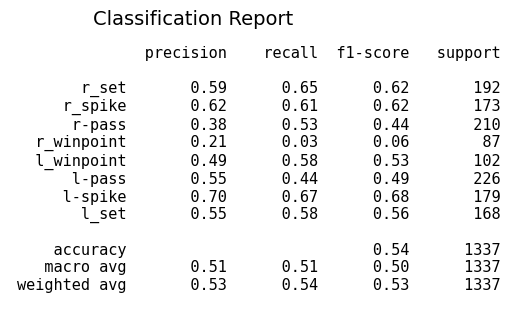

In [110]:
display_classification_report(y_true, y_pred, model_config.group_classes_names)

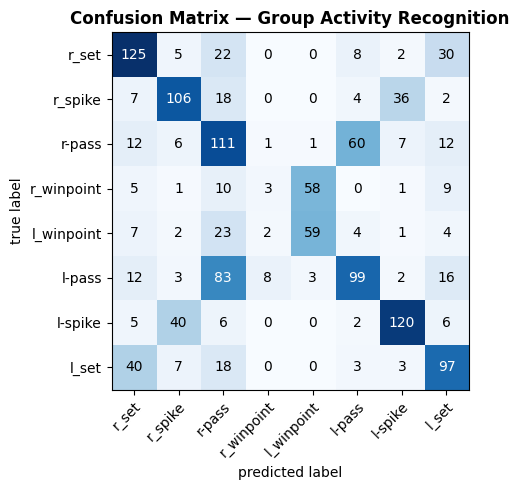

In [121]:
display_confusion_matrix(y_true, y_pred, model_config.group_classes_names)

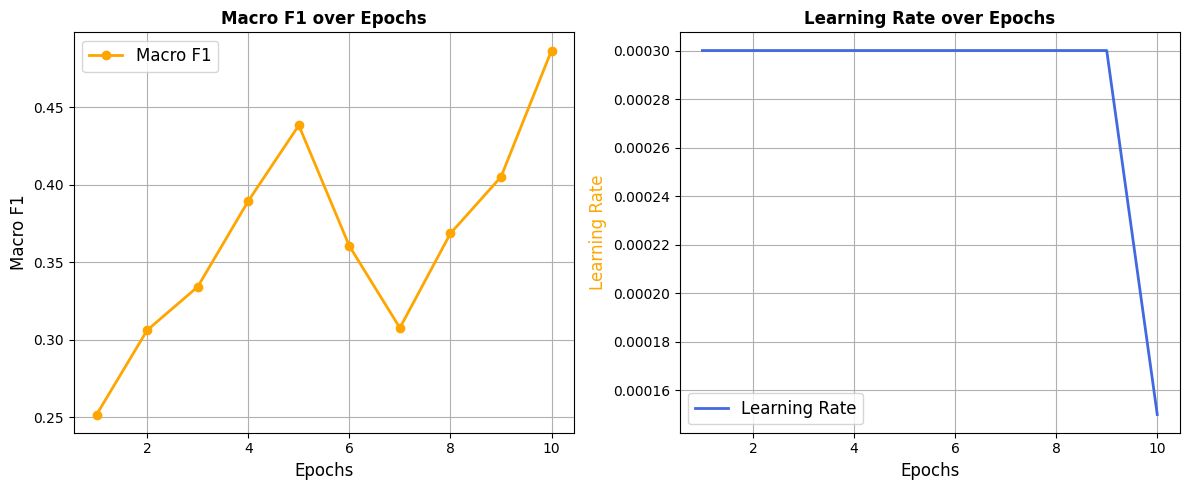

In [105]:
plot_macro_f1_and_lr(epochs, macro_f1, lr_history)

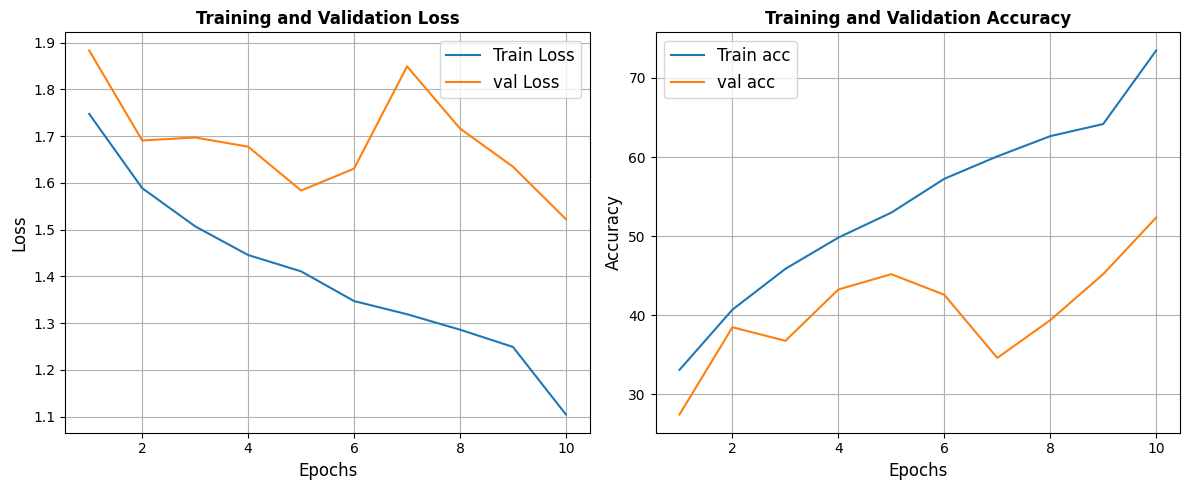

In [106]:
plot_training_curves(epochs,
                          train_losses, val_losses, train_acc, val_acc)

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Thanks & Upvote ❤️</div>